<a href="https://colab.research.google.com/github/aayurganesh2007-max/Neural_Networks_with_pytorch/blob/main/claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

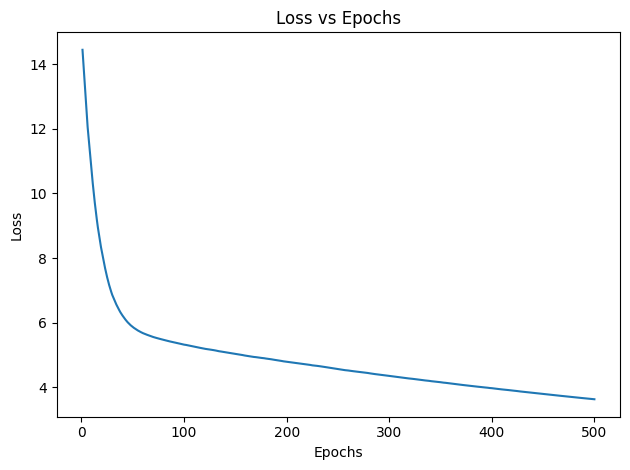

tensor(6.4104)
Mean Absolute Error: 4.695313745574951
Mean Squared Error: 41.09366283682602
R-squared: 0.8211290149912613


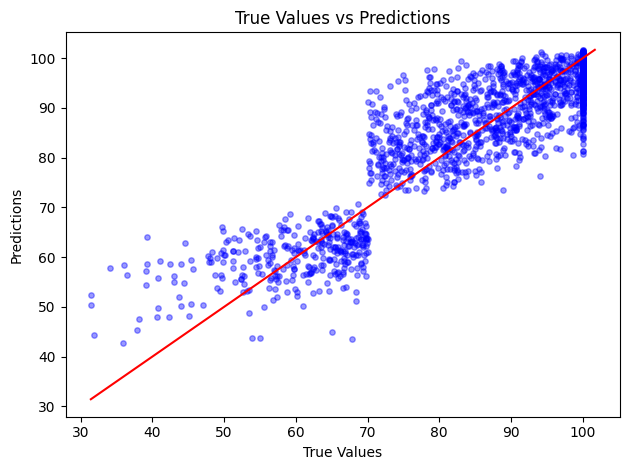

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# ── Load Data ──────────────────────────────────────────────
URL = ("https://raw.githubusercontent.com/aayurganesh2007-max/"
       "Neural_Networks_with_pytorch/refs/heads/main/student_dataset_10000_rows.csv")
df = pd.read_csv(URL)

# ── Clean ──────────────────────────────────────────────────
df.dropna(inplace=True)
le = LabelEncoder()
df["placement_encoded"] = le.fit_transform(df["placement_status"])
df.drop(columns=["placement_status"], inplace=True)

# ── Feature Engineering ────────────────────────────────────
df["study_efficiency"]  = df["study_hours"] * df["attendance"] / 100
df["score_momentum"]    = df["previous_score"] * df["attendance"] / 100
df["distraction_index"] = df["internet_usage"] / (df["assignments_completed"] + 1)
df["sleep_study_ratio"] = df["sleep_hours"] / (df["study_hours"] + 1)
df["assignment_rate"]   = df["assignments_completed"] / (df["study_hours"] + 1)

FEATURES = [
    "study_hours", "attendance", "sleep_hours", "internet_usage",
    "assignments_completed", "previous_score", "placement_encoded",
    "study_efficiency", "score_momentum",
    "distraction_index", "sleep_study_ratio", "assignment_rate",
]
TARGET = "exam_score"

X = df[FEATURES]
y = df[TARGET]

# ── Train / Test Split ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ── Train XGBoost (track loss per epoch) ──────────────────
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=False,
)

train_loss = model.evals_result()["validation_0"]["rmse"]
epochs = list(range(1, len(train_loss) + 1))

# ── Plot 1: Loss vs Epochs ─────────────────────────────────
plt.figure()
plt.plot(epochs, train_loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.tight_layout()
plt.show()

# ── Predict & Print Metrics ────────────────────────────────
y_pred = model.predict(X_test)

test_loss = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"tensor({test_loss:.4f})")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# ── Plot 2: True vs Predicted Scatter ─────────────────────
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.4, color="blue", s=15)
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], color="red", linewidth=1.5)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True Values vs Predictions")
plt.tight_layout()
plt.show()